## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

Edited and Submitted by: Anika Manjesh

In [1]:
import pandas as pd
drinks_file = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"
drinks = pd.read_csv(drinks_file)
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [2]:
# drinks.drop(columns="total_litres_of_pure_alcohol").head()
drinks.drop(columns="total_litres_of_pure_alcohol", inplace=True)
drinks
# drinks.tidy

,country,beer_servings,spirit_servings,wine_servings
0,Afghanistan,0,0,0
1,Albania,89,132,54
2,Algeria,25,0,14
3,Andorra,245,138,312
4,Angola,217,57,45
...,...,...,...,...
188,Venezuela,333,100,3
189,Vietnam,111,2,1
190,Yemen,6,0,0
191,Zambia,32,19,4


In [3]:
drinks_tidy = drinks.melt(id_vars="country", var_name="drink", value_name="servings")
drinks_tidy

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

Namibia drinks the most Beer, France drinks the most Wine, and Grenada drinks the most spirits.

In [4]:
drinks_tidy = drinks.melt(id_vars="country", var_name="drink", value_name="servings")
drinks_tidy['drink'] = drinks_tidy['drink'].str.replace('_servings', '')
drinks_tidy

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217
...,...,...,...
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

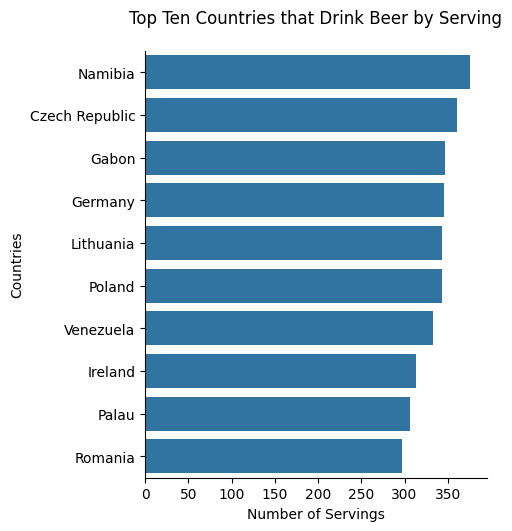

In [ ]:
beer_df = (
    drinks_tidy[drinks_tidy['drink'] == 'beer']
    .nlargest(10, 'servings')
)
sns.catplot(
    x = 'servings',
    y = 'country',
    data = beer_df,
    kind = 'bar'
).set_axis_labels('Number of Servings','Countries');
plt.title("Top Ten Countries that Drink Beer by Serving", pad=20);

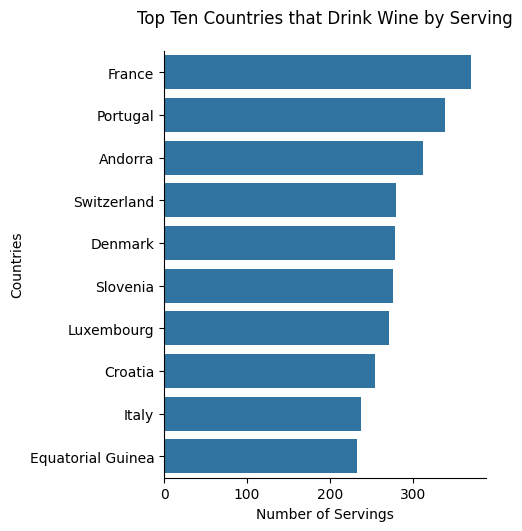

In [ ]:
wine_df = (
    drinks_tidy[drinks_tidy['drink'] == 'wine']
    .nlargest(10, 'servings')
)
sns.catplot(
    x = 'servings',
    y = 'country',
    data = wine_df,
    kind = 'bar'
).set_axis_labels('Number of Servings','Countries');
plt.title("Top Ten Countries that Drink Wine by Serving", pad=20);

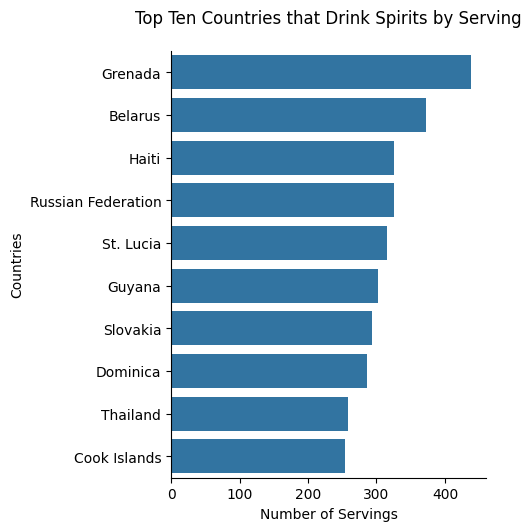

In [ ]:
spirits_df = (
    drinks_tidy[drinks_tidy['drink'] == 'spirit']
    .nlargest(10, 'servings')
)
sns.catplot(
    x = 'servings',
    y = 'country',
    data = spirits_df,
    kind = 'bar'
).set_axis_labels('Number of Servings','Countries');
plt.title("Top Ten Countries that Drink Spirits by Serving", pad=20);

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [5]:
drinks_wide = pd.pivot_table(drinks_tidy, index='country', values='servings', columns='drink')
drinks_wide

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
...,...,...,...
Venezuela,333.0,100.0,3.0
Vietnam,111.0,2.0,1.0
Yemen,6.0,0.0,0.0
